In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import nltk

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import label_binarize
from sklearn.metrics import precision_recall_curve
import joblib

In [2]:
## import excel

df = pd.read_excel("dataset_keluhan_pasien_masalah_sudah_digabungin.xlsx")
df.head()

,Postingan Keluhan,Kategori Masalah,Fitur,Penjelasan masalah + kasus,FLAG CRISIS,SKOR URGENSI
0,Saya khawatir jika anak sering tantrum di temp...,Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
1,"Karena kesulitan mencari sekolah yang sesuai, ...",Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
2,Saya membutuhkan bantuan atau solusi untuk bia...,Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
3,Saya merasa terdapat hubungan antara kesulitan...,Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
4,"Karena kurangnya dukungan keluarga, terapi ana...",Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Postingan Keluhan           250 non-null    object
 1   Kategori Masalah            250 non-null    object
 2   Fitur                       250 non-null    object
 3   Penjelasan masalah + kasus  250 non-null    object
 4   FLAG CRISIS                 250 non-null    object
 5   SKOR URGENSI                250 non-null    int64 
dtypes: int64(1), object(5)
memory usage: 11.8+ KB


In [4]:
print("Jumlah kategori masalah: ", df["Kategori Masalah"].nunique())

print("\nKategori masalah:")
print(df["Kategori Masalah"].unique())

Jumlah kategori masalah:  4

Kategori masalah:
['Dukungan' 'Gangguan Psikologis Pendamping' 'Kebutuhan Informasi'
 'Masalah Lain']


In [5]:
print("Jumlah Fitur: ", df["Fitur"].nunique())

print("\nFitur:")
print(df["Fitur"].unique())

Jumlah Fitur:  4

Fitur:
['Konsultasi' 'Komunitas' 'Edukasi' 'Konsultasi Darurat']


In [6]:
print("Jumlah Penjelasan masalah + kasus: ", df["Penjelasan masalah + kasus"].nunique())

print("\Penjelasan masalah + kasus:")
print(df["Penjelasan masalah + kasus"].unique())

Jumlah Penjelasan masalah + kasus:  5
\Penjelasan masalah + kasus:
['Saya memahami bahwa tanggung jawab pengasuhan yang terus-menerus dapat menimbulkan kelelahan fisik dan emosional. Banyak caregiver mengalami tekanan ketika harus membagi waktu antara kebutuhan anak dan aktivitas sehari-hari. Anda dapat memanfaatkan fitur Konsultasi untuk berdiskusi lebih lanjut mengenai strategi pengelolaan stres dan dukungan yang sesuai dengan kondisi Anda.'
 'Kurangnya dukungan dari lingkungan sekitar dapat membuat caregiver merasa sendirian dalam menghadapi berbagai tantangan pengasuhan. Berbagi pengalaman dengan orang lain yang memiliki situasi serupa sering kali membantu mengurangi beban emosional dan memberikan sudut pandang baru. Anda dapat memanfaatkan fitur Forum Komunitas untuk terhubung dengan caregiver lainnya.'
 'Kesulitan memperoleh informasi yang jelas mengenai ASD dapat membuat caregiver merasa bingung dalam mengambil keputusan terkait pengasuhan maupun terapi. Memahami kondisi anak se

In [7]:
## count fitur

df["Penjelasan masalah + kasus"].value_counts()

Penjelasan masalah + kasus
Saya memahami bahwa tanggung jawab pengasuhan yang terus-menerus dapat menimbulkan kelelahan fisik dan emosional. Banyak caregiver mengalami tekanan ketika harus membagi waktu antara kebutuhan anak dan aktivitas sehari-hari. Anda dapat memanfaatkan fitur Konsultasi untuk berdiskusi lebih lanjut mengenai strategi pengelolaan stres dan dukungan yang sesuai dengan kondisi Anda.                    90
Kesulitan memperoleh informasi yang jelas mengenai ASD dapat membuat caregiver merasa bingung dalam mengambil keputusan terkait pengasuhan maupun terapi. Memahami kondisi anak secara lebih baik dapat membantu meningkatkan kepercayaan diri dalam mendampingi anak sehari-hari. Anda dapat mengakses fitur Edukasi untuk memperoleh informasi dan materi yang relevan.                                    74
Untuk informasi lebih lanjut mengenai masalah tersebut, silakan melakukan konsultasi.                                                                                        

In [8]:
## count masalah

df["Kategori Masalah"].value_counts()

Kategori Masalah
Dukungan                          76
Gangguan Psikologis Pendamping    71
Kebutuhan Informasi               63
Masalah Lain                      40
Name: count, dtype: int64

In [9]:
## count FITUR

df["Fitur"].value_counts()

Fitur
Konsultasi            130
Edukasi                74
Komunitas              31
Konsultasi Darurat     15
Name: count, dtype: int64

# pre-processing

In [10]:
df_cp = df.copy()
df_cp.head()

,Postingan Keluhan,Kategori Masalah,Fitur,Penjelasan masalah + kasus,FLAG CRISIS,SKOR URGENSI
0,Saya khawatir jika anak sering tantrum di temp...,Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
1,"Karena kesulitan mencari sekolah yang sesuai, ...",Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
2,Saya membutuhkan bantuan atau solusi untuk bia...,Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
3,Saya merasa terdapat hubungan antara kesulitan...,Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3
4,"Karena kurangnya dukungan keluarga, terapi ana...",Dukungan,Konsultasi,Saya memahami bahwa tanggung jawab pengasuhan ...,NO,3


In [11]:
df_cp.duplicated().sum()

np.int64(0)

In [12]:
df_duplicated = df_cp[df_cp.duplicated()]
df_duplicated

,Postingan Keluhan,Kategori Masalah,Fitur,Penjelasan masalah + kasus,FLAG CRISIS,SKOR URGENSI


In [13]:
df_cp.drop_duplicates(inplace=True)
df_cp.reset_index(drop=True, inplace=True)
df_cp.duplicated().sum()

np.int64(0)

In [14]:
## count fitur

df_cp["Penjelasan masalah + kasus"].value_counts()

Penjelasan masalah + kasus
Saya memahami bahwa tanggung jawab pengasuhan yang terus-menerus dapat menimbulkan kelelahan fisik dan emosional. Banyak caregiver mengalami tekanan ketika harus membagi waktu antara kebutuhan anak dan aktivitas sehari-hari. Anda dapat memanfaatkan fitur Konsultasi untuk berdiskusi lebih lanjut mengenai strategi pengelolaan stres dan dukungan yang sesuai dengan kondisi Anda.                    90
Kesulitan memperoleh informasi yang jelas mengenai ASD dapat membuat caregiver merasa bingung dalam mengambil keputusan terkait pengasuhan maupun terapi. Memahami kondisi anak secara lebih baik dapat membantu meningkatkan kepercayaan diri dalam mendampingi anak sehari-hari. Anda dapat mengakses fitur Edukasi untuk memperoleh informasi dan materi yang relevan.                                    74
Untuk informasi lebih lanjut mengenai masalah tersebut, silakan melakukan konsultasi.                                                                                        

In [15]:
# split data

X = df_cp["Postingan Keluhan"]
y = df_cp["Penjelasan masalah + kasus"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(187,)
(63,)
(187,)
(63,)


In [16]:
y_train = y_train.map({ 'Untuk informasi lebih lanjut mengenai masalah tersebut, silakan melakukan konsultasi.': 0,
                        'Kesulitan memperoleh informasi yang jelas mengenai ASD dapat membuat caregiver merasa bingung dalam mengambil keputusan terkait pengasuhan maupun terapi. Memahami kondisi anak secara lebih baik dapat membantu meningkatkan kepercayaan diri dalam mendampingi anak sehari-hari. Anda dapat mengakses fitur Edukasi untuk memperoleh informasi dan materi yang relevan.': 1,
                        'Kurangnya dukungan dari lingkungan sekitar dapat membuat caregiver merasa sendirian dalam menghadapi berbagai tantangan pengasuhan. Berbagi pengalaman dengan orang lain yang memiliki situasi serupa sering kali membantu mengurangi beban emosional dan memberikan sudut pandang baru. Anda dapat memanfaatkan fitur Forum Komunitas untuk terhubung dengan caregiver lainnya.': 2,
                        'Saya memahami bahwa tanggung jawab pengasuhan yang terus-menerus dapat menimbulkan kelelahan fisik dan emosional. Banyak caregiver mengalami tekanan ketika harus membagi waktu antara kebutuhan anak dan aktivitas sehari-hari. Anda dapat memanfaatkan fitur Konsultasi untuk berdiskusi lebih lanjut mengenai strategi pengelolaan stres dan dukungan yang sesuai dengan kondisi Anda.': 3,
                        'Terima kasih telah berbagi cerita. Saya memahami bahwa situasi yang Anda hadapi tidak mudah dan dapat menimbulkan berbagai emosi. Perasaan yang Anda rasakan adalah hal yang wajar dan penting untuk mendapatkan dukungan yang sesuai. Jika Anda merasa sangat tertekan atau terdapat risiko membahayakan diri sendiri maupun orang lain, segera hubungi tenaga profesional atau layanan bantuan darurat.':4,
                        })
y_test = y_test.map({   'Untuk informasi lebih lanjut mengenai masalah tersebut, silakan melakukan konsultasi.': 0,
                        'Kesulitan memperoleh informasi yang jelas mengenai ASD dapat membuat caregiver merasa bingung dalam mengambil keputusan terkait pengasuhan maupun terapi. Memahami kondisi anak secara lebih baik dapat membantu meningkatkan kepercayaan diri dalam mendampingi anak sehari-hari. Anda dapat mengakses fitur Edukasi untuk memperoleh informasi dan materi yang relevan.': 1,
                        'Kurangnya dukungan dari lingkungan sekitar dapat membuat caregiver merasa sendirian dalam menghadapi berbagai tantangan pengasuhan. Berbagi pengalaman dengan orang lain yang memiliki situasi serupa sering kali membantu mengurangi beban emosional dan memberikan sudut pandang baru. Anda dapat memanfaatkan fitur Forum Komunitas untuk terhubung dengan caregiver lainnya.': 2,
                        'Saya memahami bahwa tanggung jawab pengasuhan yang terus-menerus dapat menimbulkan kelelahan fisik dan emosional. Banyak caregiver mengalami tekanan ketika harus membagi waktu antara kebutuhan anak dan aktivitas sehari-hari. Anda dapat memanfaatkan fitur Konsultasi untuk berdiskusi lebih lanjut mengenai strategi pengelolaan stres dan dukungan yang sesuai dengan kondisi Anda.': 3,
                        'Terima kasih telah berbagi cerita. Saya memahami bahwa situasi yang Anda hadapi tidak mudah dan dapat menimbulkan berbagai emosi. Perasaan yang Anda rasakan adalah hal yang wajar dan penting untuk mendapatkan dukungan yang sesuai. Jika Anda merasa sangat tertekan atau terdapat risiko membahayakan diri sendiri maupun orang lain, segera hubungi tenaga profesional atau layanan bantuan darurat.':4,
                        })

y_train.head()

146    3
10     2
214    0
185    1
151    3
Name: Penjelasan masalah + kasus, dtype: int64

In [17]:
y_train.value_counts()

Penjelasan masalah + kasus
3    67
1    56
0    30
2    23
4    11
Name: count, dtype: int64

In [18]:
## apply pre-processing for indonesian text
%pip install Sastrawi

# import StemmerFactory class
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# stemming process
sentence = 'Perekonomian Indonesia sedang dalam pertumbuhan yang membanggakan'
output   = stemmer.stem(sentence)

print(output)
# ekonomi indonesia sedang dalam tumbuh yang bangga

print(stemmer.stem('Mereka meniru-nirukannya'))
# mereka tiru

Note: you may need to restart the kernel to use updated packages.
ekonomi indonesia sedang dalam tumbuh yang bangga



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


mereka tiru


In [19]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Yasmin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yasmin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Yasmin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Yasmin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [20]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

# stopwords
indonesian_stopwords = set(stopwords.words("indonesian"))

def clean(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) #Replacing all non-alphabetic characters with a space
    text = text.lower().strip() #converting to lowecase
    text = word_tokenize(text)
    text = [stemmer.stem(word) for word in text if word not in indonesian_stopwords]
    text = ' '.join(text)
    return text

X_train_clean = X_train.apply(clean)
X_test_clean = X_test.apply(clean)

X_train_clean.head()

146                         kendala damping terapi
10     lingkung paham kondisi anak cenderung tutup
214                             lambat macet jalan
185       perilaku anak sulit psikolog asd bingung
151           kendala besar kurang dukung keluarga
Name: Postingan Keluhan, dtype: object

In [21]:
X_train.iloc[0]

'Saya terkendala oleh harus mendampingi terapi setiap hari.'

In [22]:
X_train_clean.shape

(187,)

In [23]:
# vectorization
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

X_train_tfidf.dtype

dtype('float64')

In [24]:
# oversampling
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

In [25]:
y_train_resampled.value_counts()

Penjelasan masalah + kasus
3    67
2    67
0    67
1    67
4    67
Name: count, dtype: int64

# Modelling

In [26]:
def classification_eval(actual, predict, name):

  cm = confusion_matrix(actual, predict)
  # plot confusion matrix
  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
              xticklabels=['0', '1', '2', '3', '4'],
              yticklabels=['0', '1', '2', '3', '4'])
  plt.xlabel('Predicted Labels')
  plt.ylabel('Actual Lables')
  plt.title(f'Confusion Matrix - {name}')
  plt.show()

  print(classification_report(actual, predict, zero_division=0))

In [27]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-NN': KNeighborsClassifier(),
    'Support Vector Machine': SVC(random_state=42, probability=True)
}

results = []

for model_name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred_test = model.predict(X_test_tfidf)
    y_prob_test = model.predict_proba(X_test_tfidf)

    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
    recall_test = recall_score(y_test, y_pred_test, average='weighted')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    auc_test = roc_auc_score(y_test, y_prob_test, average='weighted', multi_class='ovr')

    results.append({
        'Model': model_name,
        'Test Recall': recall_test,
        'Test Precision': precision_test,
        'Test Accuracy': accuracy_test,
        'Test F-1': f1_test,
        'Test AUC': auc_test
    })

df_accuracy = pd.DataFrame(results).sort_values(by=['Test Recall', 'Test Precision', 'Test Accuracy', 'Test F-1', 'Test AUC'], ascending=False)
df_accuracy

,Model,Test Recall,Test Precision,Test Accuracy,Test F-1,Test AUC
5,Support Vector Machine,0.873016,0.886544,0.873016,0.866249,0.994420
3,Random Forest,0.809524,0.812410,0.809524,0.808744,0.938117
1,Logistic Regression,0.761905,0.741643,0.761905,0.729736,0.978345
0,Naive Bayes,0.666667,0.586985,0.666667,0.577919,0.968835
2,Decision Tree,0.650794,0.694444,0.650794,0.651618,0.752542
4,K-NN,0.634921,0.749008,0.634921,0.634921,0.872974


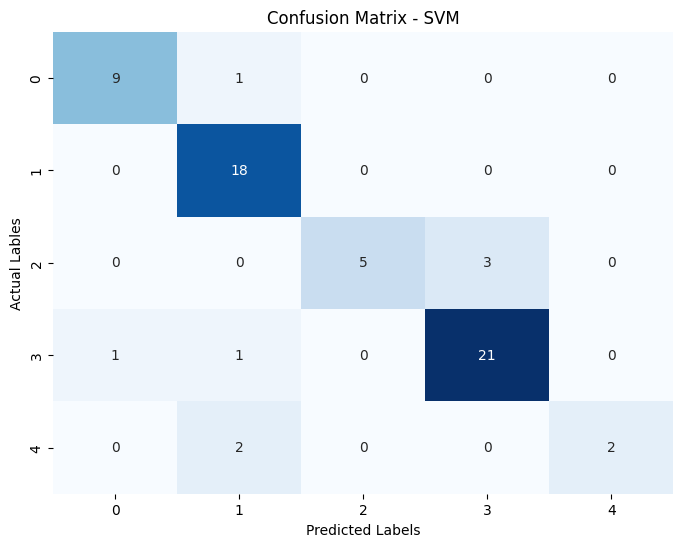

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.82      1.00      0.90        18
           2       1.00      0.62      0.77         8
           3       0.88      0.91      0.89        23
           4       1.00      0.50      0.67         4

    accuracy                           0.87        63
   macro avg       0.92      0.79      0.83        63
weighted avg       0.89      0.87      0.87        63



In [28]:
# train again svm

# Enable probability=True to allow the use of predict_proba()
svc = SVC(random_state=42, probability=True)
model = svc.fit(X_train_tfidf, y_train)
y_pred_test = model.predict(X_test_tfidf)
y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]

classification_eval(y_test, y_pred_test, 'SVM')

In [29]:
def get_optimal_thresholds(y_true, y_score, n_classes=4):
    """
    Compute optimal thresholds for each class using F1-score maximization.
    
    Parameters:
    - y_true: Binary labels (shape: n_samples, n_classes)
    - y_score: Predicted probabilities (shape: n_samples, n_classes)
    - n_classes: Number of classes
    
    Returns:
    - optimal_thresholds: Dict with threshold for each class
    - f1_scores_per_class: Dict with max F1 score for each class
    """
    optimal_thresholds = {}
    f1_scores_per_class = {}
    
    for i in range(n_classes):
        precision, recall, thresholds = precision_recall_curve(y_true[:, i], y_score[:, i])
        
        # Calculate F1 scores
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
        
        # Find optimal threshold
        optimal_idx = np.argmax(f1_scores)
        optimal_thresholds[i] = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
        f1_scores_per_class[i] = f1_scores[optimal_idx]
    
    return optimal_thresholds, f1_scores_per_class

def apply_threshold_prediction(y_score, optimal_thresholds):
    """
    Apply optimal thresholds to probability scores and return class predictions.
    
    Parameters:
    - y_score: Predicted probabilities (shape: n_samples, n_classes)
    - optimal_thresholds: Dict with threshold for each class
    
    Returns:
    - y_pred_threshold: Predicted class labels using threshold
    """
    y_pred_threshold = np.zeros(len(y_score), dtype=int)
    
    for idx in range(len(y_score)):
        scores = y_score[idx]
        # Gunakan threshold optimal per kelas
        pred_binary = [1 if scores[i] >= optimal_thresholds[i] else 0 for i in range(len(scores))]
        
        # Jika tidak ada kelas yang lolos threshold, gunakan argmax
        if sum(pred_binary) == 0:
            y_pred_threshold[idx] = np.argmax(scores)
        else:
            # Ambil kelas dengan probabilitas tertinggi yang lolos threshold
            y_pred_threshold[idx] = np.argmax([scores[i] * pred_binary[i] for i in range(len(scores))])
    
    return y_pred_threshold


=== THRESHOLD TUNING - SVC Model ===

Optimal Thresholds per Class (SVC):
  0 (Class 0): 0.8155 (F1: 0.9000)
  1 (Class 1): 0.5087 (F1: 0.9730)
  2 (Class 2): 0.7523 (F1: 1.0000)
  3 (Class 3): 0.2150 (F1: 0.9778)
  4 (Class 4): 0.9674 (F1: 1.0000)

--- Performance Comparison (SVC) ---
Accuracy (Default): 0.8730
Accuracy (Threshold): 0.9683
Precision (Default): 0.8865
Precision (Threshold): 0.9691
Recall (Default): 0.8730
Recall (Threshold): 0.9683
F1-Score (Default): 0.8662
F1-Score (Threshold): 0.9683

--- Confusion Matrix dengan Optimal Threshold (SVC) ---


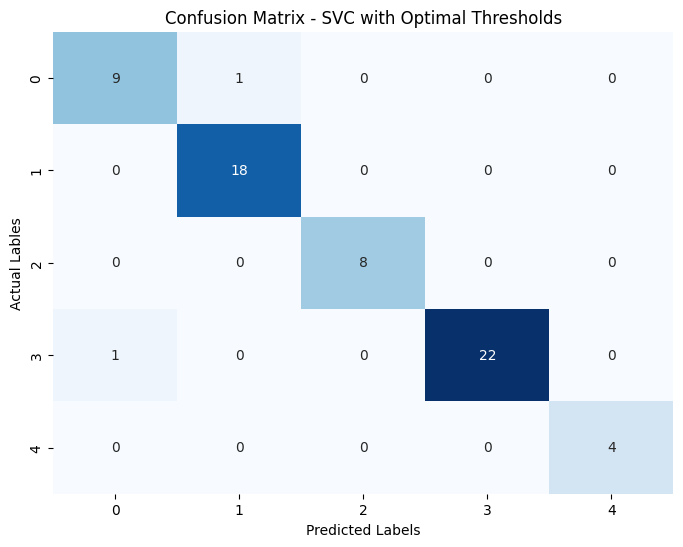

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.95      1.00      0.97        18
           2       1.00      1.00      1.00         8
           3       1.00      0.96      0.98        23
           4       1.00      1.00      1.00         4

    accuracy                           0.97        63
   macro avg       0.97      0.97      0.97        63
weighted avg       0.97      0.97      0.97        63



In [30]:
# ===== THRESHOLD TUNING untuk SVC =====
print("\n=== THRESHOLD TUNING - SVC Model ===")

# Binarize test labels untuk threshold calculation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
y_score_svc = model.predict_proba(X_test_tfidf)

# Hitung optimal thresholds dengan melimpahkan n_classes=5
optimal_thresholds_svc, f1_scores_svc = get_optimal_thresholds(y_test_bin, y_score_svc, n_classes=5)

print("\nOptimal Thresholds per Class (SVC):")
class_names = ['0', '1', '2', '3', '4']
for i   , class_name in enumerate(class_names):
    print(f"  {class_name} (Class {i}): {optimal_thresholds_svc[i]:.4f} (F1: {f1_scores_svc[i]:.4f})")

# Apply threshold-based predictions
y_pred_threshold_svc = apply_threshold_prediction(y_score_svc, optimal_thresholds_svc)

# Compare metrics: Default vs Threshold-based
print("\n--- Performance Comparison (SVC) ---")
print(f"Accuracy (Default): {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Accuracy (Threshold): {accuracy_score(y_test, y_pred_threshold_svc):.4f}")
print(f"Precision (Default): {precision_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"Precision (Threshold): {precision_score(y_test, y_pred_threshold_svc, average='weighted'):.4f}")
print(f"Recall (Default): {recall_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"Recall (Threshold): {recall_score(y_test, y_pred_threshold_svc, average='weighted'):.4f}")
print(f"F1-Score (Default): {f1_score(y_test, y_pred_test, average='weighted'):.4f}")
print(f"F1-Score (Threshold): {f1_score(y_test, y_pred_threshold_svc, average='weighted'):.4f}")

print("\n--- Confusion Matrix dengan Optimal Threshold (SVC) ---")
classification_eval(y_test, y_pred_threshold_svc, 'SVC with Optimal Thresholds')

In [31]:
# ===== INTERACTIVE USER INPUT PREDICTION =====
class_labels = ['Untuk informasi lebih lanjut mengenai masalah tersebut, silakan melakukan konsultasi.',
                'Kesulitan memperoleh informasi yang jelas mengenai ASD dapat membuat caregiver merasa bingung dalam mengambil keputusan terkait pengasuhan maupun terapi. Memahami kondisi anak secara lebih baik dapat membantu meningkatkan kepercayaan diri dalam mendampingi anak sehari-hari. Anda dapat mengakses fitur Edukasi untuk memperoleh informasi dan materi yang relevan.',
                'Kurangnya dukungan dari lingkungan sekitar dapat membuat caregiver merasa sendirian dalam menghadapi berbagai tantangan pengasuhan. Berbagi pengalaman dengan orang lain yang memiliki situasi serupa sering kali membantu mengurangi beban emosional dan memberikan sudut pandang baru. Anda dapat memanfaatkan fitur Forum Komunitas untuk terhubung dengan caregiver lainnya.',
                'Saya memahami bahwa tanggung jawab pengasuhan yang terus-menerus dapat menimbulkan kelelahan fisik dan emosional. Banyak caregiver mengalami tekanan ketika harus membagi waktu antara kebutuhan anak dan aktivitas sehari-hari. Anda dapat memanfaatkan fitur Konsultasi untuk berdiskusi lebih lanjut mengenai strategi pengelolaan stres dan dukungan yang sesuai dengan kondisi Anda.',
                'Terima kasih telah berbagi cerita. Saya memahami bahwa situasi yang Anda hadapi tidak mudah dan dapat menimbulkan berbagai emosi. Perasaan yang Anda rasakan adalah hal yang wajar dan penting untuk mendapatkan dukungan yang sesuai. Jika Anda merasa sangat tertekan atau terdapat risiko membahayakan diri sendiri maupun orang lain, segera hubungi tenaga profesional atau layanan bantuan darurat.']

def preprocess_user_input(text):
    """
    Preprocess user input dengan cleaning dan stemming
    """
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower().strip()
    text = word_tokenize(text)
    text = [stemmer.stem(word) for word in text if word not in indonesian_stopwords]
    text = ' '.join(text)
    return text

def predict_with_threshold(text, model, thresholds, model_name="Model"):
    """
    Predict dengan threshold tuning dan tampilkan detail hasil
    """
    # Preprocess
    cleaned_text = preprocess_user_input(text)
    
    # Vectorize
    text_tfidf = tfidf.transform([cleaned_text])
    
    # Get probabilities
    probabilities = model.predict_proba(text_tfidf)[0]
    
    # Default prediction
    pred_default = model.predict(text_tfidf)[0]
    
    # Threshold-based prediction
    pred_threshold = apply_threshold_prediction(probabilities.reshape(1, -1), thresholds)[0]
    
    return {
        'original_text': text,
        'cleaned_text': cleaned_text,
        'probabilities': probabilities,
        'pred_default': pred_default,
        'pred_threshold': pred_threshold,
        'thresholds': thresholds,
        'model_name': model_name
    }

def display_prediction_result(result):
    """
    Tampilkan hasil prediksi dengan format yang rapi
    """
    print("\n" + "="*80)
    print(f"MODEL: {result['model_name']}")
    print("="*80)
    
    print(f"\n📝 TEKS INPUT ASLI:")
    print(f"   {result['original_text']}")
    
    print(f"\n🔍 TEKS SETELAH PREPROCESSING:")
    print(f"   {result['cleaned_text']}")
    
    print(f"\n📊 PROBABILITAS PER KELAS:")
    for i, class_name in enumerate(class_labels):
        prob = result['probabilities'][i]
        threshold = result['thresholds'][i]
        status = "✓ LOLOS" if prob >= threshold else "✗ TIDAK"
        bar_length = int(prob * 30)
        bar = "█" * bar_length + "░" * (30 - bar_length)
        print(f"   {class_name:20} [{bar}] {prob:.4f} (Threshold: {threshold:.4f}) {status}")
    
    print(f"\n🎯 HASIL PREDIKSI:")
    print(f"   Default (argmax)      : {class_labels[result['pred_default']]}")
    print(f"   Threshold-based       : {class_labels[result['pred_threshold']]}")

In [32]:
user_input = input("\nMasukkan teks keluhan pasien (atau ketik 'quit' untuk keluar): ")

result_user = predict_with_threshold(user_input, model, optimal_thresholds_svc, "SVC")
display_prediction_result(result_user)


MODEL: SVC

📝 TEKS INPUT ASLI:
   

🔍 TEKS SETELAH PREPROCESSING:
   

📊 PROBABILITAS PER KELAS:
   Untuk informasi lebih lanjut mengenai masalah tersebut, silakan melakukan konsultasi. [█████████████████████████░░░░░] 0.8591 (Threshold: 0.8155) ✓ LOLOS
   Kesulitan memperoleh informasi yang jelas mengenai ASD dapat membuat caregiver merasa bingung dalam mengambil keputusan terkait pengasuhan maupun terapi. Memahami kondisi anak secara lebih baik dapat membantu meningkatkan kepercayaan diri dalam mendampingi anak sehari-hari. Anda dapat mengakses fitur Edukasi untuk memperoleh informasi dan materi yang relevan. [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.0417 (Threshold: 0.5087) ✗ TIDAK
   Kurangnya dukungan dari lingkungan sekitar dapat membuat caregiver merasa sendirian dalam menghadapi berbagai tantangan pengasuhan. Berbagi pengalaman dengan orang lain yang memiliki situasi serupa sering kali membantu mengurangi beban emosional dan memberikan sudut pandang baru. Anda dapat memanfaatkan fitu